# A/B Testing — chiến dịch voucher

**Mục tiêu:** đo hiệu quả của voucher lên nhóm khách hàng mục tiêu (Cụm 2 — *Khách cuối tuần, trả Flex, tip thấp*)



#### Mục lục

| Phần | Nội dung |
|---|---|
| **1. Thiết kế Experiment** | |
| 1.1 Chọn đối tượng thí nghiệm | population vs sample, lọc rider cụm target |
| 1.2 Hypothesis & Metrics | H₀/H₁ · primary metric · **ngưỡng hoà vốn** |
| 1.3 Power Analysis | **MDE** · so với ngưỡng hoà vốn · kết luận đủ power hay không |
| **2. Kiểm tra Randomization** | |
| 2.1 Sample Ratio Mismatch | binomial test |
| 2.2 Covariate Balance | SMD 11 biến số + biến phân loại · Love plot · ngưỡng ±0.10 |
| **3. Ước lượng Tác động** | ATE · Welch t-test · KTC 95% |
| **4. Monte Carlo Validation** | bốc lại `T` **1.000 lần** × 5 mức effect size · **bias** · **coverage 95%** · **power** (sai lầm loại I tại `s` = 0) |
| **5. Đánh giá Kinh doanh** | incremental trips · revenue · voucher cost · net profit · **ROI** · **CPIT** · khuyến nghị rollout |
| **6. Xuất Kết quả** | summary tables · CSV outputs · figures |

---

## SET UP

In [16]:
# Import thư viện
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

# Khai báo đường dẫn dữ liệu
B    = r"c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing Promotions"
SRC  = os.path.join(B, "02. Synthetic_data", "output", "experiment_ab_final.csv")
SEG  = os.path.join(B, "03. Segmentation", "outputs", "rider_cluster.csv")
OUT  = os.path.join(B, "04. AB Testing", "output"); os.makedirs(OUT, exist_ok=True)

SEED = 42                      # dung cho Monte Carlo o muc 4

# Màu sắc
SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES, ALT     = "#e1e0d9", "#c3c2b7", "#2a78d6", "#eb6834"


df  = pd.read_csv(SRC)
seg = pd.read_csv(SEG)[["user_id", "cluster", "persona", "is_target"]]

_before = len(df)
df = df.merge(seg, on="user_id", how="inner", validate="1:1")
assert len(df) == _before, f"merge mat dong: {_before:,} -> {len(df):,}"

## 1. Thiết kế Experiment

### 1.1 Chọn đối tượng thí nghiệm
Đơn vị là **rider**: mỗi người hoặc nhận voucher, hoặc không.

In [17]:
tg = df[df.is_target == 1].copy()

TARGET_CLUSTER = int(tg.cluster.iloc[0])
TARGET         = tg.persona.iloc[0]
t_, c_         = tg[tg.T_rct == 1], tg[tg.T_rct == 0]

assert tg.cluster.nunique() == 1, "nhom target trai tren nhieu cum — kiem tra buoc 03"

print(f"Cum {TARGET_CLUSTER} — {TARGET}")
print(f"   quy mo    : {len(tg):,} rider ({len(tg)/len(df):.1%})")
print(f"   treatment : {len(t_):,}")
print(f"   control   : {len(c_):,}")

Cum 2 — Khach cuoi tuan, tra Flex, tip thap
   quy mo    : 6,446 rider (32.2%)
   treatment : 3,216
   control   : 3,230


### 1.2 Hypothesis & Metrics

**Hypothesis**

| | |
|---|---|
| H₀ | Voucher không làm thay đổi số chuyến trung bình của rider thuộc cụm target |
| H₁ | Voucher làm tăng số chuyến trung bình |
| Primary metric | **Incremental Trips per Rider** — chênh lệch số chuyến/30 ngày giữa nhóm nhận và không nhận |
| Đơn vị ngẫu nhiên hoá | rider |

Cần một ngưỡng kinh tế — **ngưỡng hoà vốn**: mức tăng tối thiểu để chiến dịch không lỗ.
Giả sử: 
$$\text{BREAKEVEN} = \frac{\text{giá trị voucher}}{\text{doanh thu biên mỗi chuyến}} = \frac{V}{\overline{fare} \times \text{take rate}}$$

In [18]:
# Một rider phải tạo thêm bao nhiêu chuyến thì mới bù được chi phí voucher.
# Giả sử
VOUCHER_VALUE = 5.00     # USD moi rider duoc gui voucher
TAKE_RATE     = 0.20     # ty le hoa hong nen tang giu lai tren moi chuyen

# Tính ngưỡng hoà vốn: bao nhiêu chuyến/rider thì hoa hồng bù đủ giá trị voucher
def breakeven(fare_mean):
    """Uplift toi thieu de hoa von, tinh bang chuyen/rider."""
    return VOUCHER_VALUE / (fare_mean * TAKE_RATE)

BREAKEVEN = breakeven(tg.avg_fare.mean())

print(f"Gia tri voucher        : ${VOUCHER_VALUE:.2f} / rider")
print(f"Cuoc TB cum target     : ${tg.avg_fare.mean():.2f} / chuyen")
print(f"Doanh thu bien / chuyen: ${tg.avg_fare.mean() * TAKE_RATE:.2f}")
print(f"Nguong hoa von         : {BREAKEVEN:.4f} chuyen / rider")

Gia tri voucher        : $5.00 / rider
Cuoc TB cum target     : $22.67 / chuyen
Doanh thu bien / chuyen: $4.53
Nguong hoa von         : 1.1027 chuyen / rider


### 1.3 Power Analysis

**MDE** (Minimum Detectable Effect) là tác động nhỏ nhất mà thí nghiệm ở quy mô này còn phát hiện được với power 80%:

$$\text{MDE} = (z_{1-\alpha/2} + z_{\text{power}}) \times SE$$

`SE` phải khớp **cách bốc thăm**. `T` bốc theo khối, nên độ lệch chuẩn dùng ở đây là **SD trong khối** của nhánh control — trừ trung bình từng khối trước khi tính. Dùng SD thô sẽ tính cả biến thiên *giữa* các khối, phần mà thiết kế đã khử, làm MDE to lên giả tạo.

Thí nghiệm chỉ **đủ sức** nếu `MDE < BREAKEVEN`.

In [19]:
ALPHA, POWER = 0.05, 0.80
z_a, z_b     = stats.norm.ppf(1 - ALPHA / 2), stats.norm.ppf(POWER)

# SE thiet ke phai khop cach boc tham: T boc theo KHOI, nen SD dung o day la
# SD TRONG KHOI cua nhanh control (tru trung binh tung khoi truoc khi tinh).
c0      = tg[tg.T_rct == 0]
_res    = c0.Y_rct - c0.groupby("block_id").Y_rct.transform("mean")
sd0     = float(np.sqrt((_res ** 2).sum() / (len(c0) - c0.block_id.nunique())))
sd0_tho = float(c0.Y_rct.std(ddof=1))            # SD tho, chi de doi chieu

n1, n0 = len(t_), len(c_)
se_d   = sd0 * np.sqrt(1 / n1 + 1 / n0)          # SE duoi gia dinh thiet ke
MDE    = (z_a + z_b) * se_d

mde_tab = pd.DataFrame([{
    "segment": TARGET, "n": len(tg), "treated": n1, "control": n0,
    "SD(Y0) trong khoi": sd0, "SE thiet ke": se_d,
    "MDE": MDE, "BREAKEVEN": BREAKEVEN,
    "MDE < BREAKEVEN?": "DU SUC" if MDE < BREAKEVEN else "THIEU LUC"}]).round(4)
display(mde_tab)

print(f"MDE {MDE:.4f} {'<' if MDE < BREAKEVEN else '>='} BREAKEVEN {BREAKEVEN:.4f}  ->  "
      f"thi nghiem {'DU SUC' if MDE < BREAKEVEN else 'THIEU LUC'} phat hien tac dong "
      f"o nguong hoa von.")
print(f"SD(Y0): trong khoi {sd0:.4f} vs tho {sd0_tho:.4f} — dung SD tho cho MDE "
      f"{(z_a + z_b) * sd0_tho * np.sqrt(1 / n1 + 1 / n0):.4f}, phinh "
      f"{sd0_tho / sd0 - 1:+.2%} vi tinh ca bien thien GIUA cac khoi ma thiet ke da khu.")

,segment,n,treated,control,SD(Y0) trong khoi,SE thiet ke,MDE,BREAKEVEN,MDE < BREAKEVEN?
0,"Khach cuoi tuan, tra Flex, tip thap",6446,3216,3230,5.5373,0.1379,0.3864,1.1027,DU SUC


MDE 0.3864 < BREAKEVEN 1.1027  ->  thi nghiem DU SUC phat hien tac dong o nguong hoa von.
SD(Y0): trong khoi 5.5373 vs tho 6.7534 — dung SD tho cho MDE 0.4713, phinh +21.96% vi tinh ca bien thien GIUA cac khoi ma thiet ke da khu.


## 2. Kiểm tra Randomization

### 2.1 Sample Ratio Mismatch (SRM)


In [20]:
from scipy.stats import binomtest

n_t, n_c = len(t_), len(c_)
srm = binomtest(n_t, n_t + n_c, 0.5)
print(f"Ty le chia nhom : {n_t:,} / {n_c:,}  ({n_t/(n_t+n_c):.1%} treatment)")
print(f"SRM binomial p  : {srm.pvalue:.4f}  ->  {'OK' if srm.pvalue > 0.001 else 'CO SRM - dung lai'}")

Ty le chia nhom : 3,216 / 3,230  (49.9% treatment)
SRM binomial p  : 0.8714  ->  OK


### 2.2 Covariate Balance

In [21]:
# Các covariate dùng để kiểm tra cân bằng
COV = ["total_rides", "recency_days", "typical_distance", "route_entropy",
       "pct_airport", "weekend_ratio", "pct_flex_payment", "pct_tip_rate",
       "avg_fare", "age", "is_urban"]

# Hàm tính Standardized Mean Difference (SMD)
# SMD = (mean_treatment - mean_control) / pooled_std
# |SMD| < 0.1: Hai nhóm được xem là cân bằng.
# |SMD| càng lớn: Hai nhóm càng khác nhau.
def smd(a, b):
    """Standardized Mean Difference — chenh lech chia do lech chuan gop."""
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return 0.0 if s == 0 else (a.mean() - b.mean()) / s

# Tính:
# - Giá trị trung bình của từng covariate trong Treatment
# - Giá trị trung bình trong Control
# - SMD giữa hai nhóm
bal = pd.DataFrame({
    "treatment": [t_[c].mean() for c in COV],
    "control":   [c_[c].mean() for c in COV],
    "SMD":       [smd(t_[c], c_[c]) for c in COV],
}, index=COV)

# Lấy trị tuyệt đối của SMD và sắp xếp theo mức mất cân bằng giảm dần.
bal["|SMD|"] = bal.SMD.abs()
bal = bal.sort_values("|SMD|", ascending=False)

# Hiển thị bảng kiểm tra cân bằng
display(bal.round(4))
print(f"|SMD| lon nhat = {bal['|SMD|'].max():.4f}  ->  "
      f"{'CAN BANG' if bal['|SMD|'].max() < 0.1 else 'MAT CAN BANG'}")

,treatment,control,SMD,|SMD|
typical_distance,2.9964,3.0529,-0.0306,0.0306
recency_days,14.7077,15.4294,-0.0302,0.0302
total_rides,21.7665,21.4464,0.0201,0.0201
route_entropy,2.7512,2.7355,0.0171,0.0171
avg_fare,22.6166,22.7275,-0.0157,0.0157
weekend_ratio,0.3805,0.3829,-0.0141,0.0141
age,41.2195,41.3641,-0.0104,0.0104
pct_flex_payment,0.4108,0.4096,0.0077,0.0077
pct_tip_rate,0.2160,0.2161,-0.0026,0.0026
is_urban,0.8411,0.8402,0.0023,0.0023


|SMD| lon nhat = 0.0306  ->  CAN BANG


In [22]:
# SMD cho bien PHAN LOAI: tinh tren tung muc cua bien phan loai
CAT = ["gender", "home_borough", "pref_time_bucket"]
rows = []
# Tính SMD cho từng mức của biến phân loại
for col in CAT:
    for lev in sorted(tg[col].dropna().unique()):
        a = (t_[col] == lev).astype(float)
        b = (c_[col] == lev).astype(float)
        rows.append({"bien": f"{col} = {lev}", "treatment": a.mean(),
                     "control": b.mean(), "SMD": smd(a, b)})
# Tạo bảng hiển thị kết quả SMD cho từng mức của biến phân loại
bal_cat = pd.DataFrame(rows)
bal_cat["|SMD|"] = bal_cat.SMD.abs()
bal_cat = bal_cat.sort_values("|SMD|", ascending=False).reset_index(drop=True)
display(bal_cat.round(4))
_m = bal_cat["|SMD|"].max()
print(f"|SMD| lon nhat tren bien phan loai = {_m:.4f}  ->  "
      f"{'CAN BANG' if _m < 0.1 else 'MAT CAN BANG'}")

,bien,treatment,control,SMD,|SMD|
0,home_borough = Brooklyn,0.0361,0.0477,-0.0580,0.0580
1,pref_time_bucket = evening,0.2565,0.2718,-0.0347,0.0347
2,home_borough = Queens,0.1191,0.1087,0.0328,0.0328
3,pref_time_bucket = morning,0.1720,0.1647,0.0194,0.0194
4,gender = Female,0.3333,0.3260,0.0156,0.0156
5,gender = Other,0.3433,0.3483,-0.0105,0.0105
6,pref_time_bucket = late_night,0.3455,0.3409,0.0097,0.0097
7,pref_time_bucket = midday,0.2261,0.2226,0.0083,0.0083
8,home_borough = Bronx,0.0037,0.0034,0.0055,0.0055
9,gender = Male,0.3234,0.3257,-0.0049,0.0049


|SMD| lon nhat tren bien phan loai = 0.0580  ->  CAN BANG


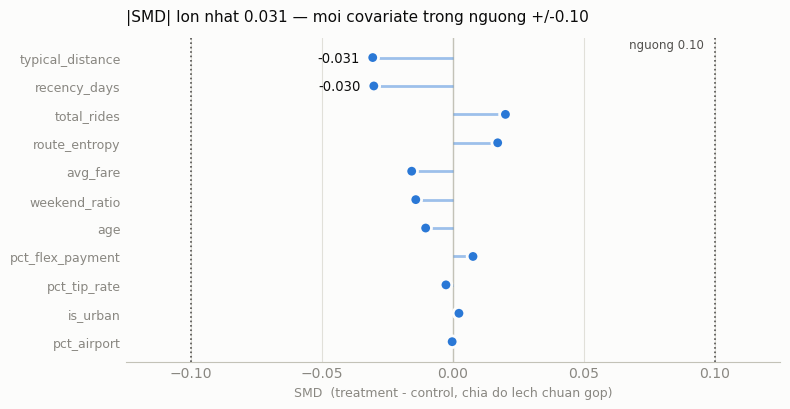

In [23]:
THR = 0.10

# Tạo figure hiển thị SMD của các covariate.
fig, ax = plt.subplots(figsize=(8, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Sắp xếp covariate theo |SMD| tăng dần để dễ quan sát.
o   = bal.sort_values("|SMD|")  

# Tọa độ Y của từng covariate.            
y   = np.arange(len(o))
col = [SERIES if v < THR else ALT for v in o["|SMD|"]]

# Vẽ đường tham chiếu:
# - x = 0: hai nhóm có trung bình bằng nhau.
# - ±THR: ngưỡng đánh giá cân bằng.
ax.axvline(0, color=AXIS, lw=1, zorder=1)
for x in (-THR, THR):
    ax.axvline(x, color=SECOND, lw=1.2, ls=":", zorder=1)
ax.text(THR - .004, len(o) - .55, f"nguong {THR:.2f}", color=SECOND,
        fontsize=8.5, va="center", ha="right")

# Vẽ lollipop chart:
# - Đường ngang biểu diễn giá trị SMD.
# - Điểm tròn đánh dấu vị trí SMD của từng covariate.
ax.hlines(y, 0, o.SMD, color=col, lw=2, alpha=.45)
ax.scatter(o.SMD, y, s=70, color=col, zorder=3,
           edgecolor=SURFACE, linewidth=2)

# Hiển thị giá trị SMD của hai covariate lệch nhiều nhất.
for i in (len(o) - 1, len(o) - 2):
    v = o.SMD.iloc[i]
    ax.text(v + (.005 if v >= 0 else -.005), i, f"{v:+.3f}", color=INK,
            fontsize=9.5, va="center", ha="left" if v >= 0 else "right")

# Định dạng biểu đồ:
# - Giới hạn trục.
# - Hiển thị tên covariate.
# - Thêm grid và tiêu đề.
ax.set_xlim(-THR * 1.25, THR * 1.25)
ax.set_ylim(-.7, len(o) - .3)
ax.set_yticks(y)
ax.set_yticklabels(o.index, fontsize=9, color=SECOND)
ax.set_xlabel("SMD  (treatment - control, chia do lech chuan gop)",
              fontsize=9, color=MUTED)
ax.xaxis.grid(True, color=GRID, lw=.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0)
_mx  = bal["|SMD|"].max()
_txt = "moi covariate trong nguong" if _mx < THR else "CO COVARIATE VUOT NGUONG"
ax.set_title(f"|SMD| lon nhat {_mx:.3f} — {_txt} +/-{THR:.2f}",
             fontsize=11, color=INK, loc="left", pad=12)
plt.tight_layout()
plt.show()

## 3. Ước lượng Tác động

Estimator khớp thiết kế: hồi quy `Y ~ T + block dummies`, sai số chuẩn **HC1**. Bỏ qua khối thì SE bị phóng đại — mục 4 đo được coverage ~0.98 và sai lầm loại I ~0.025 thay vì 0.95 / 0.05.

In [24]:
def ols_hc1(X, y, j=1):
    """(he so_j, SE HC1_j). Dung solve thay cho nghich dao ma tran truc tiep."""
    XtX   = X.T @ X
    beta  = np.linalg.solve(XtX, X.T @ y)
    r     = y - X @ beta
    nn, k = X.shape
    meat  = (X * (r ** 2)[:, None]).T @ X
    A     = np.linalg.solve(XtX, meat)                 # XtX^-1 @ meat
    V     = np.linalg.solve(XtX, A.T).T * nn / (nn - k)
    return beta[j], np.sqrt(V[j, j])


# Y ~ T + block dummies. BLOCK_D dung lai o muc 4.
BLOCK_D = pd.get_dummies(tg.block_id, drop_first=True).to_numpy(float)
X_fe    = np.column_stack([np.ones(len(tg)), tg.T_rct.to_numpy(float), BLOCK_D])

UPLIFT, SE = ols_hc1(X_fe, tg.Y_rct.to_numpy(float))
_dfree     = len(tg) - X_fe.shape[1]
_q         = stats.t.ppf(1 - ALPHA / 2, _dfree)
LO, HI     = UPLIFT - _q * SE, UPLIFT + _q * SE
PVAL       = 2 * stats.t.sf(abs(UPLIFT / SE), _dfree)
LIFT       = UPLIFT / c_.Y_rct.mean()

print(f"Y trung binh    : treatment {t_.Y_rct.mean():.4f} | control {c_.Y_rct.mean():.4f}")
print(f"Uplift / rider  : {UPLIFT:+.4f} chuyen / 30 ngay   (Y ~ T + block FE, SE HC1)")
print(f"SE              : {SE:.4f}")
print(f"KTC 95%         : [{LO:.4f}, {HI:.4f}]")
print(f"Lift tuong doi  : {LIFT:.1%}")
print(f"p-value         : {PVAL:.4g}")
print(f"\nH0: {'BAC BO' if PVAL < ALPHA else 'CHUA bac bo'}   |   "
      f"Vuot BREAKEVEN: {'CO' if LO > BREAKEVEN else 'KHONG chac (KTC cham nguong hoa von)'}")

# Doi chieu: neu bo qua khoi (hieu so tho + SE Welch)
_d  = t_.Y_rct.mean() - c_.Y_rct.mean()
_se = np.sqrt(t_.Y_rct.var(ddof=1) / len(t_) + c_.Y_rct.var(ddof=1) / len(c_))
print(f"\nBo qua khoi (Welch): uplift {_d:+.4f}, SE {_se:.4f} — SE rong hon {_se / SE - 1:+.1%}.")

Y trung binh    : treatment 9.1001 | control 7.3201
Uplift / rider  : +1.6671 chuyen / 30 ngay   (Y ~ T + block FE, SE HC1)
SE              : 0.1406
KTC 95%         : [1.3915, 1.9428]
Lift tuong doi  : 22.8%
p-value         : 4.284e-32

H0: BAC BO   |   Vuot BREAKEVEN: CO

Bo qua khoi (Welch): uplift +1.7800, SE 0.1703 — SE rong hon +21.1%.


## 4. Monte Carlo Validation

**Cách làm:** giữ nguyên `Y₀`/`Y₁`, chỉ **bốc lại `T`** 1.000 lần theo đúng thiết kế gốc (50% mỗi khối). Lặp ở 5 mức effect size `s`

| Báo cáo | Ý nghĩa | Mong đợi |
|---|---|---|
| **bias** | TB ước lượng − tác động thật | ≈ 0 |
| **coverage** | % lần KTC 95% phủ tác động thật | ≈ 95% |
| **power** | % lần KTC 95% không chứa 0 | |

In [ ]:
# Tai lap hai potential outcome tu du lieu synthetic
Y0    = (tg.Y_rct - tg.ite_realized * tg.T_rct).to_numpy(float)   # so chuyen neu KHONG nhan voucher
TAU_I = tg.ite_realized.to_numpy(float)                           # tac dong that cua tung rider

ate_true     = float(tg.cate_true.mean())      # estimand cau truc
ate_realized = float(TAU_I.mean())             # estimand huu han mau — RCT nham toi

print(f"ate_true     = {ate_true:.4f} chuyen / rider")
print(f"ate_realized = {ate_realized:.4f} chuyen / rider   <- estimand cua nhanh RCT\n")

# Boc lai T: 50% trong tung khoi, giong het thiet ke goc 
n_tg   = len(tg)
blocks = list(tg.reset_index(drop=True).groupby("block_id").indices.values())

def draw_T(rng):
    T = np.zeros(n_tg)
    for ix in blocks:
        T[rng.choice(ix, int(round(len(ix) * 0.5)), replace=False)] = 1.0
    return T


R      = 1000                              # so lan mo phong
SCALES = [0.0, 0.10, 0.25, 0.50, 1.00]     # vai muc effect size
z      = stats.norm.ppf(1 - ALPHA / 2)
rng    = np.random.default_rng(SEED)

# Dung lai ols_hc1 va BLOCK_D cua muc 3; cap phat MOT lan, moi vong ghi de cot T.
X      = np.column_stack([np.ones(n_tg), np.zeros(n_tg), BLOCK_D])

recs = []
for s in SCALES:
    truth   = s * ate_realized             # tac dong that o muc s nay
    est, se = np.empty(R), np.empty(R)
    for r in range(R):
        T = draw_T(rng)
        Y = Y0 + s * TAU_I * T             # Y1 = Y0 + s * ite_realized
        X[:, 1] = T
        est[r], se[r] = ols_hc1(X, Y)      # dung lai estimator cua muc 3
    lo, hi = est - z * se, est + z * se
    recs.append({"he so s": s, "tac dong that": truth, "TB uoc luong": est.mean(),
                 "bias": est.mean() - truth,
                 "coverage": ((lo <= truth) & (truth <= hi)).mean(),
                 "power": ((lo > 0) | (hi < 0)).mean()})

mc = pd.DataFrame(recs)
display(mc.round(4))
print(f"{len(SCALES)} muc effect size x {R:,} lan boc lai T = {len(SCALES) * R:,} thi nghiem mo phong")

ate_true     = 1.5315 chuyen / rider
ate_realized = 1.5290 chuyen / rider   <- estimand cua nhanh RCT



,he so s,tac dong that,TB uoc luong,bias,coverage,power
0,0.00,0.0000,0.0021,0.0021,0.951,0.049
1,0.10,0.1529,0.1467,-0.0062,0.950,0.172
2,0.25,0.3823,0.3848,0.0026,0.946,0.795
3,0.50,0.7645,0.7624,-0.0021,0.952,0.999
4,1.00,1.5290,1.5287,-0.0003,0.962,1.000


5 muc effect size x 1,000 lan boc lai T = 5,000 thi nghiem mo phong


In [26]:
_t1 = float(mc.loc[mc["he so s"] == 0, "power"].iloc[0])

print(f"Bias     : lon nhat {mc.bias.abs().max():.4f} — estimator khong thien vi.")
print(f"Coverage : [{mc.coverage.min():.3f}, {mc.coverage.max():.3f}] quanh muc danh nghia 0.95, "
      f"on dinh o moi muc tac dong.")
print(f"Sai lam loai I (s = 0): {_t1:.3f} — "
      f"{'DAT' if 0.03 <= _t1 <= 0.07 else 'LECH'} so voi muc danh nghia 0.05.")

_ok = mc[(mc["he so s"] > 0) & (mc.power >= 0.80)]
if len(_ok):
    print(f"Power >= 80% tu tac dong {_ok['tac dong that'].iloc[0]:.4f} chuyen/rider "
          f"(MDE giai tich o muc 1.3: {MDE:.4f})")

Bias     : lon nhat 0.0062 — estimator khong thien vi.
Coverage : [0.946, 0.962] quanh muc danh nghia 0.95, on dinh o moi muc tac dong.
Sai lam loai I (s = 0): 0.049 — DAT so voi muc danh nghia 0.05.
Power >= 80% tu tac dong 0.7645 chuyen/rider (MDE giai tich o muc 1.3: 0.3864)


## 5. Đánh giá Kinh doanh

Chỉ khi cả ba đều đạt mới nên triển khai.

| Câu hỏi | Căn cứ |
|---|---|
| Có **tác động** không? | p-value và KTC ở mục 3 |
| Đủ **hoà vốn** không? | cận dưới KTC so với `BREAKEVEN` |
| Ước lượng có **đáng tin** không? | bias và coverage ở mục 4 |

In [27]:
N_ROLLOUT   = len(tg)
MARGIN      = tg.avg_fare.mean() * TAKE_RATE     # doanh thu bien moi chuyen
INC_TRIPS   = UPLIFT * N_ROLLOUT
COST        = VOUCHER_VALUE * N_ROLLOUT
INC_REVENUE = INC_TRIPS * MARGIN
NET         = INC_REVENUE - COST
ROI         = NET / COST
CPIT        = COST / INC_TRIPS                   # chi phi / incremental trip

econ = pd.DataFrame({
    "chi so": ["Rider duoc gui voucher", "Incremental trips", "Chi phi voucher",
               "Doanh thu bien tang them", "Loi nhuan rong", "ROI",
               "Chi phi / incremental trip"],
    "gia tri": [f"{N_ROLLOUT:,}", f"{INC_TRIPS:,.0f}", f"${COST:,.0f}",
                f"${INC_REVENUE:,.0f}", f"${NET:,.0f}", f"{ROI:.1%}", f"${CPIT:.2f}"]})
display(econ)

print(f"Hoa von khi uplift = BREAKEVEN {BREAKEVEN:.4f}; thuc te {UPLIFT:.4f} "
      f"(gap {UPLIFT / BREAKEVEN:.2f} lan).")
print(f"Kich ban than trong (dung can duoi KTC {LO:.4f}): ROI "
      f"{(LO * N_ROLLOUT * MARGIN - COST) / COST:.1%}, "
      f"${VOUCHER_VALUE / LO:.2f} moi chuyen tang them.")

,chi so,gia tri
0,Rider duoc gui voucher,"6,446"
1,Incremental trips,"10,746"
2,Chi phi voucher,"$32,230"
3,Doanh thu bien tang them,"$48,729"
4,Loi nhuan rong,"$16,499"
5,ROI,51.2%
6,Chi phi / incremental trip,$3.00


Hoa von khi uplift = BREAKEVEN 1.1027; thuc te 1.6671 (gap 1.51 lan).
Kich ban than trong (dung can duoi KTC 1.3915): ROI 26.2%, $3.59 moi chuyen tang them.


In [28]:
_sig   = PVAL < ALPHA
_prof  = LO > BREAKEVEN
_valid = (mc.bias.abs().max() < 0.05) and (0.93 <= mc.coverage.min() <= mc.coverage.max() <= 0.97)

print("KET LUAN")
print(f"1. Co tac dong?     uplift {UPLIFT:+.4f} chuyen/rider, p = {PVAL:.3g}"
      f"  ->  {'CO' if _sig else 'KHONG'}")
print(f"2. Du hoa von?      can duoi KTC {LO:.4f} vs BREAKEVEN {BREAKEVEN:.4f}"
      f"  ->  {'CO' if _prof else 'KHONG CHAC'}")
print(f"3. Uoc luong tin?   bias {mc.bias.abs().max():.4f}, coverage "
      f"[{mc.coverage.min():.3f}, {mc.coverage.max():.3f}]"
      f"  ->  {'DAT' if _valid else 'CAN XEM LAI'}")

print(f"\n=> {'TRIEN KHAI' if (_sig and _prof and _valid) else 'CHUA TRIEN KHAI'} "
      f"cho {N_ROLLOUT:,} rider cum target.")
print(f"   Loi nhuan rong ${NET:,.0f} | ROI {ROI:.1%} | ${CPIT:.2f} moi chuyen tang them")

KET LUAN
1. Co tac dong?     uplift +1.6671 chuyen/rider, p = 4.28e-32  ->  CO
2. Du hoa von?      can duoi KTC 1.3915 vs BREAKEVEN 1.1027  ->  CO
3. Uoc luong tin?   bias 0.0062, coverage [0.946, 0.962]  ->  DAT

=> TRIEN KHAI cho 6,446 rider cum target.
   Loi nhuan rong $16,499 | ROI 51.2% | $3.00 moi chuyen tang them


## 6. Xuất Kết quả

In [29]:
_mc1 = mc[mc["he so s"] == 1.0].iloc[0]          # lat s = 1 — the gioi that

summary = pd.DataFrame({
    "chi so": ["cum target", "so rider", "uplift / rider", "SE", "KTC 95% thap",
               "KTC 95% cao", "lift tuong doi", "p-value", "MDE", "BREAKEVEN",
               "ate_true", "ate_realized (estimand RCT)", "bias (MC)", "coverage (MC)",
               "sai lam loai I (MC)", "ROI", "chi phi / incremental trip"],
    "gia tri": [TARGET_CLUSTER, N_ROLLOUT, round(UPLIFT, 4), round(SE, 4), round(LO, 4),
                round(HI, 4), f"{LIFT:.1%}", f"{PVAL:.4g}", round(MDE, 4), round(BREAKEVEN, 4),
                round(ate_true, 4), round(ate_realized, 4),
                round(float(_mc1.bias), 4), round(float(_mc1.coverage), 4),
                round(float(mc.loc[mc["he so s"] == 0, "power"].iloc[0]), 4),
                f"{ROI:.1%}", f"${CPIT:.2f}"]})
display(summary)

_files = {"ab_summary.csv": summary, "power_analysis.csv": mde_tab,
          "montecarlo_validation.csv": mc.round(4), "economics.csv": econ,
          "balance_rct.csv": bal.round(4)}
for fn, d in _files.items():
    d.to_csv(os.path.join(OUT, fn), index=(fn == "balance_rct.csv"))
    print(f"  {fn:<28} {os.path.getsize(os.path.join(OUT, fn)):>7,} bytes")

,chi so,gia tri
0,cum target,2
1,so rider,6446
2,uplift / rider,1.6671
3,SE,0.1406
4,KTC 95% thap,1.3915
5,KTC 95% cao,1.9428
6,lift tuong doi,22.8%
7,p-value,4.284e-32
8,MDE,0.3864
9,BREAKEVEN,1.1027


  ab_summary.csv                   355 bytes
  power_analysis.csv               177 bytes
  montecarlo_validation.csv        243 bytes
  economics.csv                    210 bytes
  balance_rct.csv                  497 bytes
